In [2]:
import pandas as pd

df = pd.read_csv("../data/train.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (9800, 18)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Monthly sales
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

# Convert index
monthly_sales.index = monthly_sales.index.to_timestamp()

print(monthly_sales.head())

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

ValueError: time data "15/04/2018" doesn't match format "%m/%d/%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

Order Date
2015-01-01    14205.707
2015-02-01     4519.892
2015-03-01    55205.797
2015-04-01    27906.855
2015-05-01    23644.303
Freq: MS, Name: Sales, dtype: float64


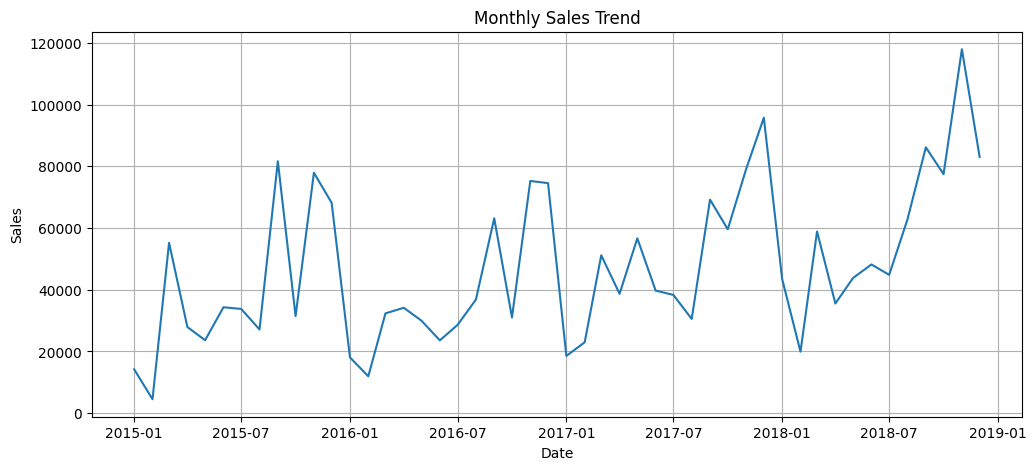

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Order Date correctly
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Monthly Sales
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales.index = monthly_sales.index.to_timestamp()

print(monthly_sales.head())

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Create time index
monthly_sales_df = monthly_sales.reset_index()
monthly_sales_df.columns = ['Date', 'Sales']

monthly_sales_df['Month_Number'] = np.arange(len(monthly_sales_df))

# Train model
X = monthly_sales_df[['Month_Number']]
y = monthly_sales_df['Sales']

model = LinearRegression()
model.fit(X, y)

# Predict next 12 months
future_months = np.arange(len(monthly_sales_df),
                          len(monthly_sales_df) + 12).reshape(-1, 1)

future_predictions = model.predict(future_months)

print("Future Sales Predictions:")
print(future_predictions)

C:\Users\E.V.S_Niveditha\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Future Sales Predictions:
[68878.99833333 69767.31052491 70655.6227165  71543.93490808
 72432.24709966 73320.55929124 74208.87148282 75097.1836744
 75985.49586599 76873.80805757 77762.12024915 78650.43244073]


In [9]:
import matplotlib.pyplot as plt
import pandas as pd

future_dates = pd.date_range(
    start=monthly_sales_df['Date'].max(),
    periods=13,
    freq='M'
)[1:]

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales_df['Date'],
    monthly_sales_df['Sales'],
    label='Actual Sales'
)

plt.plot(
    future_dates,
    future_predictions,
    label='Forecast Sales'
)

plt.title("Sales Forecast for Next 12 Months")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

ValueError: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")

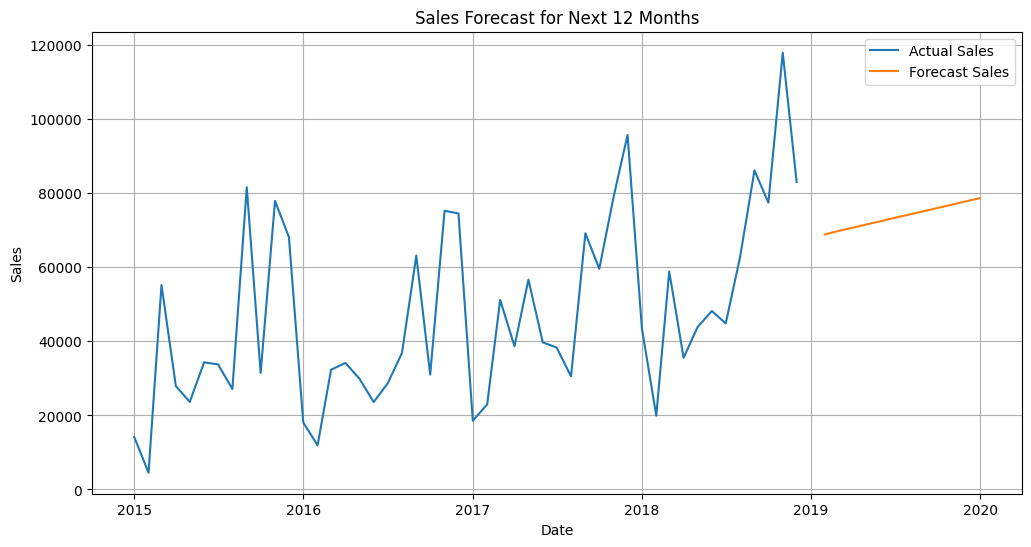

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

future_dates = pd.date_range(
    start=monthly_sales_df['Date'].max(),
    periods=13,
    freq='ME'
)[1:]

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales_df['Date'],
    monthly_sales_df['Sales'],
    label='Actual Sales'
)

plt.plot(
    future_dates,
    future_predictions,
    label='Forecast Sales'
)

plt.title("Sales Forecast for Next 12 Months")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [11]:
from sklearn.metrics import mean_absolute_error

predictions = model.predict(X)

mae = mean_absolute_error(y, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 17400.980583528202
